# Linux Special Permissions — Expanded Edition (SUID, SGID, Sticky Bit)

*A companion to `Lesson3-Linux_Special_Permissions_Sticky_SUID_SGID.ipynb`, going deeper on the
same three bits, with worked diagrams, a UID-switching simulation, a section on Linux
**capabilities** as the modern replacement for most SUID use cases, and an expanded lab/quiz.*

**This notebook does not replace the original** — read that one first for the core definitions;
this one adds the material it left out and renders the ideas visually.

> **Safety warning, repeated:** never experiment with SUID/SGID on real system binaries (`cat`,
> `bash`, `python3`, editors, copy tools). Use a disposable VM or container for anything privileged.
> Every code cell in this notebook is either a **pure Python simulation/diagram** (safe to run
> anywhere) or a **markdown reference block** you'd run yourself on a real Linux box — nothing
> here touches real file ownership or SUID bits on your machine.

### What's new compared to the original lesson
- A full 12-bit layout diagram (3 special + 9 regular), not just a table
- A visual walk-through of the sticky-bit "who can delete what" scenario
- A real-UID vs. effective-UID diagram for SUID, plus a small Python simulation of the concept
- An SGID directory-inheritance tree diagram
- A colour-coded comparison matrix rendered as an actual image, not just a markdown table
- **Linux capabilities** (`setcap`, `CAP_NET_BIND_SERVICE`, etc.) as the modern, narrower
  alternative to blanket SUID-root — missing from the original entirely
- A short, factual note on the class of SUID vulnerabilities (PATH hijacking, symlink races) and
  why "small, audited, no shell-out" is the defining rule for safe privileged binaries
- Expanded, scenario-based quiz questions in addition to the original's recall questions

Also note: the original lesson's *code* cells contained raw Bash commands under a **Python 3**
kernel, which will not actually execute there. This notebook keeps Linux commands as clearly
labelled ```bash reference blocks and reserves real "code" cells for Python that actually runs.

## 1. Review: the full 12-bit mode, visualised

A Linux mode is 12 bits: 3 *special* bits (SUID, SGID, sticky) plus the 9 ordinary `rwxrwxrwx`
bits for owner/group/other.

| Special bit | Octal value | Main use |
|---|---:|---|
| SUID | `4000` | Run an executable with the file owner's effective UID |
| SGID | `2000` | Run with the file group's effective GID, or make a directory's new entries inherit its group |
| Sticky | `1000` | Restrict deletion/renaming inside a shared, writable directory |

```text
4755 = SUID + rwxr-xr-x
2755 = SGID + rwxr-xr-x
1777 = sticky + rwxrwxrwx
6755 = SUID + SGID + rwxr-xr-x
```

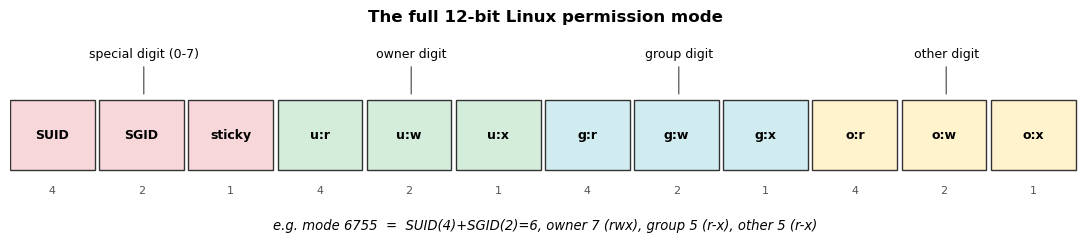

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis("off")

labels = ["SUID", "SGID", "sticky", "u:r", "u:w", "u:x", "g:r", "g:w", "g:x", "o:r", "o:w", "o:x"]
colors = ["#f8d7da"]*3 + ["#d4edda"]*3 + ["#d1ecf1"]*3 + ["#fff3cd"]*3
weights = ["4", "2", "1", "4", "2", "1", "4", "2", "1", "4", "2", "1"]

for i, (lab, col, w) in enumerate(zip(labels, colors, weights)):
    ax.add_patch(plt.Rectangle((i, 1.0), 0.95, 1.0, facecolor=col, edgecolor="#333"))
    ax.text(i + 0.475, 1.5, lab, ha="center", va="center", fontsize=9, weight="bold")
    ax.text(i + 0.475, 0.7, w, ha="center", va="center", fontsize=8, color="#555")

ax.annotate("special digit (0-7)", xy=(1.5, 2.05), xytext=(1.5, 2.6), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="-", color="#666"))
ax.annotate("owner digit", xy=(4.5, 2.05), xytext=(4.5, 2.6), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="-", color="#666"))
ax.annotate("group digit", xy=(7.5, 2.05), xytext=(7.5, 2.6), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="-", color="#666"))
ax.annotate("other digit", xy=(10.5, 2.05), xytext=(10.5, 2.6), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="-", color="#666"))

ax.text(6, 0.15, "e.g. mode 6755  =  SUID(4)+SGID(2)=6, owner 7 (rwx), group 5 (r-x), other 5 (r-x)",
        ha="center", fontsize=9.5, style="italic")

plt.title("The full 12-bit Linux permission mode", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

### How special bits appear in `ls -l`

Special letters replace the execute position of the class they belong to:

```text
-rwsr-xr-x  SUID set AND owner-execute set      (lowercase s)
-rwSr-xr-x  SUID set, owner-execute NOT set     (uppercase S)
-rwxr-sr-x  SGID set AND group-execute set      (lowercase s)
-rwxr-Sr-x  SGID set, group-execute NOT set     (uppercase S)
drwxrwxrwt  sticky set AND other-execute set    (lowercase t)
drwxrwxrwT  sticky set, other-execute NOT set   (uppercase T)
```

Lowercase = the special bit **and** the matching execute bit are both on. Uppercase = the special
bit is on but execute is off (a valid, if unusual, combination — e.g. a SUID file that no one can
actually execute).

In [2]:
def decode_mode(symbolic):
    '''Take a 10-char ls -l style string (e.g. "-rwsr-xr-x") and explain every special-bit
    position in plain language.'''
    assert len(symbolic) == 10, "expected the full 10-character ls -l string"
    ftype, owner, group, other = symbolic[0], symbolic[1:4], symbolic[4:7], symbolic[7:10]

    print(f"Input: {symbolic}")
    print(f"  file type field: {ftype!r}")

    def explain_class(name, chunk, special_char_upper, special_char_lower, special_name):
        r, w, x = chunk[0], chunk[1], chunk[2]
        base = f"{name}: read={'yes' if r=='r' else 'no'}, write={'yes' if w=='w' else 'no'}"
        if x == special_char_lower.lower():
            base += f", {special_name} SET and execute SET"
        elif x == special_char_upper:
            base += f", {special_name} SET but execute NOT set"
        elif x == "x":
            base += ", execute=yes (no special bit)"
        else:
            base += ", execute=no (no special bit)"
        print("  " + base)

    explain_class("owner", owner, "S", "s", "SUID")
    explain_class("group", group, "S", "s", "SGID")
    explain_class("other", other, "T", "t", "sticky")

for example in ["-rwsr-xr-x", "-rwSr-xr-x", "-rwxr-sr-x", "drwxrwxrwt", "drwxrwxrwT"]:
    decode_mode(example)
    print()

Input: -rwsr-xr-x
  file type field: '-'
  owner: read=yes, write=yes, SUID SET and execute SET
  group: read=yes, write=no, execute=yes (no special bit)
  other: read=yes, write=no, execute=yes (no special bit)

Input: -rwSr-xr-x
  file type field: '-'
  owner: read=yes, write=yes, SUID SET but execute NOT set
  group: read=yes, write=no, execute=yes (no special bit)
  other: read=yes, write=no, execute=yes (no special bit)

Input: -rwxr-sr-x
  file type field: '-'
  owner: read=yes, write=yes, execute=yes (no special bit)
  group: read=yes, write=no, SGID SET and execute SET
  other: read=yes, write=no, execute=yes (no special bit)

Input: drwxrwxrwt
  file type field: 'd'
  owner: read=yes, write=yes, execute=yes (no special bit)
  group: read=yes, write=yes, execute=yes (no special bit)
  other: read=yes, write=yes, sticky SET and execute SET

Input: drwxrwxrwT
  file type field: 'd'
  owner: read=yes, write=yes, execute=yes (no special bit)
  group: read=yes, write=yes, execute=ye

# Part I — Sticky Bit

## 2. What it is, and why it exists

The sticky bit matters almost entirely on **directories**. In a writable, sticky directory, a
user cannot delete or rename another user's file just because the directory itself is writable.
Normally an entry may be removed/renamed only by:

1. the file's owner,
2. the directory's owner, or
3. root.

The sticky bit does **not** stop the file's own owner from editing its contents — it only governs
*directory entry* operations (delete/rename), which is exactly the gap called out at the end of
the basic-permissions notebook: deletion is a directory-level decision.

```text
drwxrwxrwx shared/     # 0777 -- ANY user can delete ANY other user's file here
drwxrwxrwt shared/     # 1777 -- users can create files; deleting others' files is blocked
```

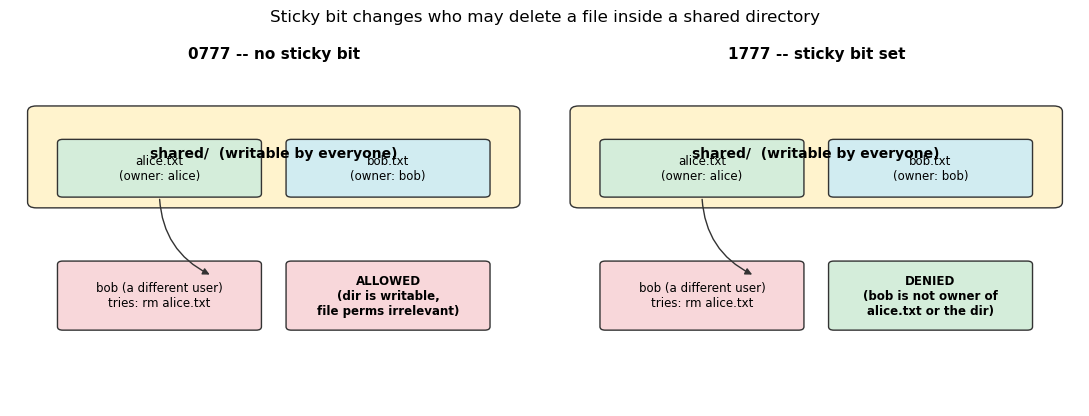

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

scenarios = [
    ("0777 -- no sticky bit", False),
    ("1777 -- sticky bit set", True),
]

for ax, (title, sticky) in zip(axes, scenarios):
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.axis("off")
    ax.set_title(title, fontsize=11, weight="bold")

    dir_color = "#fff3cd"
    ax.add_patch(FancyBboxPatch((0.3, 3.6), 5.4, 1.6, boxstyle="round,pad=0.1", facecolor=dir_color, edgecolor="#333"))
    ax.text(3, 4.4, "shared/  (writable by everyone)", ha="center", fontsize=10, weight="bold")

    ax.add_patch(FancyBboxPatch((0.6, 3.75), 2.2, 0.9, boxstyle="round,pad=0.06", facecolor="#d4edda", edgecolor="#333"))
    ax.text(1.7, 4.2, "alice.txt\n(owner: alice)", ha="center", va="center", fontsize=8.5)

    ax.add_patch(FancyBboxPatch((3.2, 3.75), 2.2, 0.9, boxstyle="round,pad=0.06", facecolor="#d1ecf1", edgecolor="#333"))
    ax.text(4.3, 4.2, "bob.txt\n(owner: bob)", ha="center", va="center", fontsize=8.5)

    ax.add_patch(FancyBboxPatch((0.6, 1.4), 2.2, 1.1, boxstyle="round,pad=0.06", facecolor="#f8d7da", edgecolor="#333"))
    ax.text(1.7, 1.95, "bob (a different user)\ntries: rm alice.txt", ha="center", va="center", fontsize=8.5)

    if sticky:
        verdict, vcolor = "DENIED\n(bob is not owner of\nalice.txt or the dir)", "#d4edda"
    else:
        verdict, vcolor = "ALLOWED\n(dir is writable,\nfile perms irrelevant)", "#f8d7da"

    ax.add_patch(FancyBboxPatch((3.2, 1.4), 2.2, 1.1, boxstyle="round,pad=0.06", facecolor=vcolor, edgecolor="#333"))
    ax.text(4.3, 1.95, verdict, ha="center", va="center", fontsize=8.5, weight="bold")

    ax.annotate("", xy=(2.3, 2.3), xytext=(1.7, 3.7),
                arrowprops=dict(arrowstyle="-|>", color="#333", connectionstyle="arc3,rad=0.3"))

plt.suptitle("Sticky bit changes who may delete a file inside a shared directory", fontsize=12)
plt.tight_layout()
plt.show()

### Enable / disable, and real-world uses

```bash
chmod +t directory        # symbolic enable
chmod -t directory        # symbolic disable
chmod 1777 directory      # numeric enable (sticky + rwxrwxrwx)
chmod 0777 directory      # numeric disable, same rwx bits kept

ls -ld /tmp
stat -c '%A %a %U %G %n' /tmp     # typically: drwxrwxrwt 1777 root root /tmp
```

Typical uses: `/tmp`, `/var/tmp`, shared upload directories, multi-user scratch/build areas,
public drop boxes — anywhere many users need write access to the *same* directory but should
only control their *own* files.

### Should `/tmp` be its own filesystem?

Not mandatory, but common on servers. Benefits: it can't fill the root filesystem, quotas/size
limits are easier to apply, and mount options like `nodev`, `nosuid`, `noexec` can be layered on.
Caution: `noexec` is not a full security boundary — installers, build tools, and language
runtimes routinely need to execute temporary helper files, so a naive `noexec /tmp` can break
things. Many modern systems mount `/tmp` as `tmpfs` (RAM-backed, cleared at reboot) instead of a
disk partition:

```text
tmpfs /tmp tmpfs defaults,nodev,nosuid,mode=1777,size=2G 0 0
```

# Part II — SUID (Set User ID)

## 3. What it is, visualised

When a user runs a valid SUID executable, the resulting process ends up with:

- **real UID** = the user who launched it (unchanged — "who you actually are")
- **effective UID** = the executable file's *owner* (this is the privileged part)

Most permission checks the kernel performs use the **effective** UID, so a root-owned SUID
executable can perform a narrow, privileged action on behalf of an ordinary user, without handing
that user a root shell.

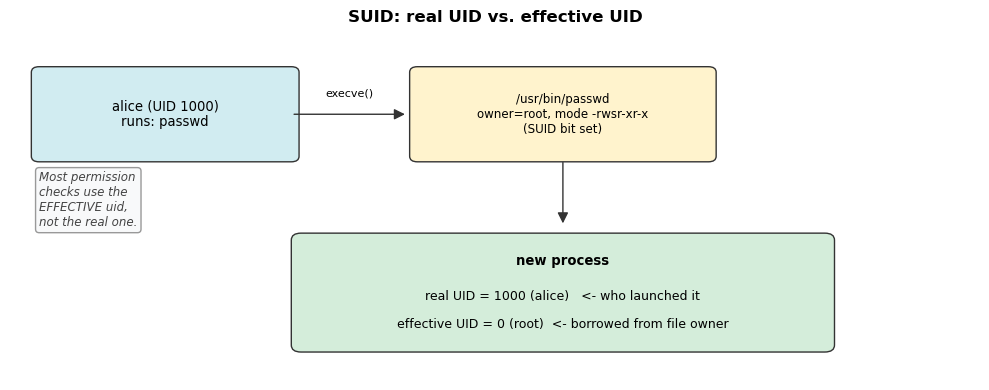

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

ax.add_patch(FancyBboxPatch((0.3, 3.2), 2.6, 1.2, boxstyle="round,pad=0.08", facecolor="#d1ecf1", edgecolor="#333"))
ax.text(1.6, 3.8, "alice (UID 1000)\nruns: passwd", ha="center", va="center", fontsize=9.5)

ax.add_patch(FancyArrowPatch((2.9, 3.8), (4.1, 3.8), arrowstyle="-|>", mutation_scale=16, color="#333"))
ax.text(3.5, 4.05, "execve()", fontsize=8, ha="center")

ax.add_patch(FancyBboxPatch((4.2, 3.2), 3.0, 1.2, boxstyle="round,pad=0.08", facecolor="#fff3cd", edgecolor="#333"))
ax.text(5.7, 3.8, "/usr/bin/passwd\nowner=root, mode -rwsr-xr-x\n(SUID bit set)", ha="center", va="center", fontsize=8.5)

ax.add_patch(FancyArrowPatch((5.7, 3.15), (5.7, 2.2), arrowstyle="-|>", mutation_scale=16, color="#333"))

ax.add_patch(FancyBboxPatch((3.0, 0.5), 5.4, 1.5, boxstyle="round,pad=0.1", facecolor="#d4edda", edgecolor="#333"))
ax.text(5.7, 1.65, "new process", ha="center", fontsize=9.5, weight="bold")
ax.text(5.7, 1.15, "real UID = 1000 (alice)   <- who launched it", ha="center", fontsize=9)
ax.text(5.7, 0.75, "effective UID = 0 (root)  <- borrowed from file owner", ha="center", fontsize=9)

ax.text(0.3, 2.2, "Most permission\nchecks use the\nEFFECTIVE uid,\nnot the real one.",
        fontsize=8.5, style="italic", color="#444",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f8f9fa", edgecolor="#999"))

plt.title("SUID: real UID vs. effective UID", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

In [5]:
# A conceptual (NOT a real privilege-escalation) simulation of what SUID changes.
# This models the idea in pure Python; it does not touch real OS permissions.

class Process:
    def __init__(self, real_uid, real_user):
        self.real_uid = real_uid
        self.real_user = real_user
        self.effective_uid = real_uid   # starts equal to real uid

    def exec(self, executable):
        print(f"{self.real_user} (real uid={self.real_uid}) runs '{executable.name}'")
        if executable.suid:
            self.effective_uid = executable.owner_uid
            print(f"  -> SUID set: effective uid becomes {self.effective_uid} "
                  f"({executable.owner_name}), real uid stays {self.real_uid}")
        else:
            print(f"  -> no SUID: effective uid stays {self.effective_uid} ({self.real_user})")

    def can_write(self, target_owner_uid):
        allowed = self.effective_uid == 0 or self.effective_uid == target_owner_uid
        verb = "CAN" if allowed else "CANNOT"
        print(f"  effective uid {self.effective_uid} {verb} write to a file owned by uid {target_owner_uid}")
        return allowed


class Executable:
    def __init__(self, name, owner_uid, owner_name, suid=False):
        self.name = name
        self.owner_uid = owner_uid
        self.owner_name = owner_name
        self.suid = suid


passwd = Executable("passwd", owner_uid=0, owner_name="root", suid=True)
ls_cmd = Executable("ls", owner_uid=0, owner_name="root", suid=False)

alice = Process(real_uid=1000, real_user="alice")
alice.exec(passwd)
alice.can_write(target_owner_uid=0)   # can now touch root-owned password data via effective uid
print()

bob = Process(real_uid=1001, real_user="bob")
bob.exec(ls_cmd)
bob.can_write(target_owner_uid=0)     # no SUID -> stays as bob, cannot write root-owned data

alice (real uid=1000) runs 'passwd'


  -> SUID set: effective uid becomes 0 (root), real uid stays 1000
  effective uid 0 CAN write to a file owned by uid 0

bob (real uid=1001) runs 'ls'
  -> no SUID: effective uid stays 1001 (bob)
  effective uid 1001 CANNOT write to a file owned by uid 0


False

### Where SUID does (and doesn't) apply

- Meaningful mainly on **compiled executable files**.
- No useful effect on ordinary data files.
- Linux generally **ignores SUID on directories**, and (for good reason) on **interpreted
  scripts** — `#!/bin/sh` scripts made SUID do not reliably run with elevated privileges on Linux.
- A filesystem mounted `nosuid` disables SUID/SGID *execution* behavior entirely, regardless of
  the bit on disk.

```bash
chmod u+s program        # enable
chmod u-s program        # disable
chmod 4755 program       # numeric enable
ls -l program             # -rwsr-xr-x if execute is also set
stat -c '%A %a %U %G %n' program
```

### Why `sudo chmod u+s /bin/cat` would be dangerous (do not run this)

If `cat` were root-owned and SUID, any user could run `cat /etc/shadow` and have the kernel
evaluate that read using effective UID 0 — bypassing the read restriction entirely. `cat` accepts
arbitrary attacker-chosen paths, so granting it root SUID converts "run cat" into "read anything
root can read." This is exactly why safe SUID programs are narrow, fixed-purpose tools (like
`passwd`), never general-purpose ones.

### Finding SUID binaries on a system (read-only, safe to run for real)

```bash
find / -xdev -type f -perm -4000 -exec ls -l {} \; 2>/dev/null
```

Useful for audits, hardening, and incident response — compare the list against a known-good
baseline; not every SUID file is a problem, but every SUID file is worth being able to explain.

# Part III — SGID (Set Group ID)

## 4. On executables vs. on directories

- **On an executable**: the process runs with the file's **group** as its effective GID (the
  group analogue of SUID).
- **On a directory**: newly created files and subdirectories **inherit the directory's group**
  instead of the creator's primary group — this is by far the more common real-world use.

```bash
chmod g+s object       # enable
chmod g-s object       # disable
chmod 2755 object      # numeric enable
```

```text
-rwxr-sr-x   SGID executable
drwxrwsr-x   SGID directory
```

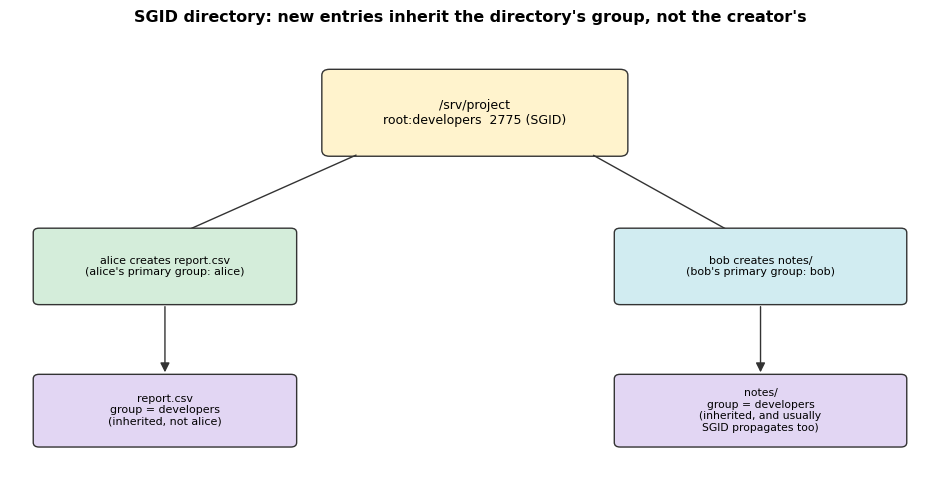

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.set_xlim(0, 9.5)
ax.set_ylim(0, 6)
ax.axis("off")

ax.add_patch(FancyBboxPatch((3.3, 4.4), 3, 1.0, boxstyle="round,pad=0.08", facecolor="#fff3cd", edgecolor="#333"))
ax.text(4.8, 4.9, "/srv/project\nroot:developers  2775 (SGID)", ha="center", va="center", fontsize=9)

ax.add_patch(FancyArrowPatch((3.6, 4.35), (1.6, 3.2), arrowstyle="-|>", mutation_scale=14, color="#333"))
ax.add_patch(FancyArrowPatch((6.0, 4.35), (7.6, 3.2), arrowstyle="-|>", mutation_scale=14, color="#333"))

ax.add_patch(FancyBboxPatch((0.3, 2.4), 2.6, 0.9, boxstyle="round,pad=0.06", facecolor="#d4edda", edgecolor="#333"))
ax.text(1.6, 2.85, "alice creates report.csv\n(alice's primary group: alice)", ha="center", va="center", fontsize=8)

ax.add_patch(FancyBboxPatch((6.3, 2.4), 2.9, 0.9, boxstyle="round,pad=0.06", facecolor="#d1ecf1", edgecolor="#333"))
ax.text(7.75, 2.85, "bob creates notes/\n(bob's primary group: bob)", ha="center", va="center", fontsize=8)

ax.add_patch(FancyArrowPatch((1.6, 2.35), (1.6, 1.4), arrowstyle="-|>", mutation_scale=14, color="#333"))
ax.add_patch(FancyArrowPatch((7.75, 2.35), (7.75, 1.4), arrowstyle="-|>", mutation_scale=14, color="#333"))

ax.add_patch(FancyBboxPatch((0.3, 0.5), 2.6, 0.85, boxstyle="round,pad=0.06", facecolor="#e2d6f3", edgecolor="#333"))
ax.text(1.6, 0.93, "report.csv\ngroup = developers\n(inherited, not alice)", ha="center", va="center", fontsize=8)

ax.add_patch(FancyBboxPatch((6.3, 0.5), 2.9, 0.85, boxstyle="round,pad=0.06", facecolor="#e2d6f3", edgecolor="#333"))
ax.text(7.75, 0.93, "notes/\ngroup = developers\n(inherited, and usually\nSGID propagates too)", ha="center", va="center", fontsize=7.8)

plt.title("SGID directory: new entries inherit the directory's group, not the creator's", fontsize=11.5, weight="bold")
plt.tight_layout()
plt.show()

### SGID does not, by itself, grant group write

SGID controls **group inheritance**, not the final permission bits. The result still depends on
`umask`, default ACLs, and the mode the creating program requested. `umask 0022` still yields
`0644` files even inside an SGID directory — collaborative projects usually pair SGID with
`umask 0002` or a default ACL:

```bash
sudo groupadd developers
sudo usermod -aG developers alice
sudo usermod -aG developers bob
sudo mkdir -p /srv/project
sudo chown root:developers /srv/project
sudo chmod 2775 /srv/project
sudo setfacl -d -m g:developers:rwx /srv/project     # default ACL: future files get group-write too
sudo setfacl -d -m o::rx /srv/project
```

Users typically need to log out/in after a group membership change for it to take effect in a new
session.

### Finding SGID files/directories

```bash
find / -xdev -type f -perm -2000 2>/dev/null
find / -xdev -type d -perm -2000 2>/dev/null
```

# Part IV — Comparison, and the modern alternative

## 5. Comparison matrix

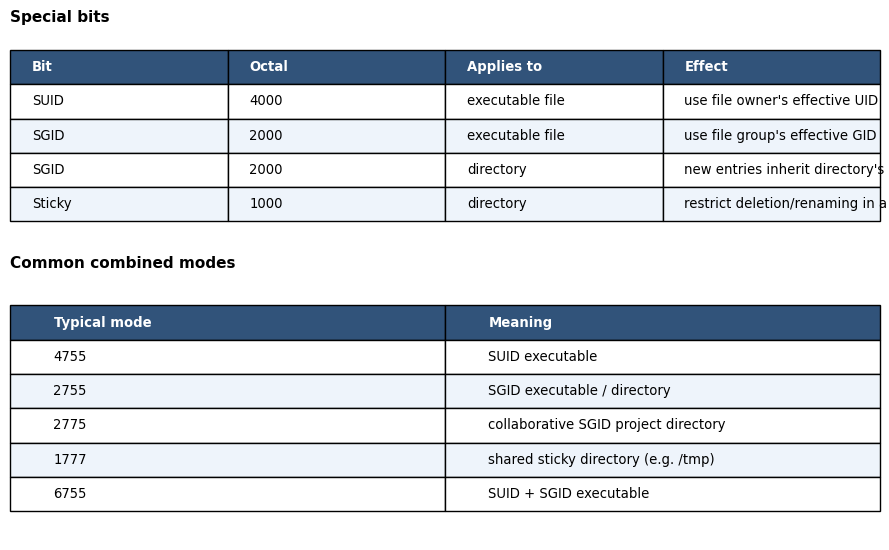

In [7]:
import matplotlib.pyplot as plt

rows = [
    ["SUID", "4000", "executable file", "use file owner's effective UID"],
    ["SGID", "2000", "executable file", "use file group's effective GID"],
    ["SGID", "2000", "directory", "new entries inherit directory's group"],
    ["Sticky", "1000", "directory", "restrict deletion/renaming in a shared writable dir"],
]
mode_rows = [
    ["4755", "SUID executable"],
    ["2755", "SGID executable / directory"],
    ["2775", "collaborative SGID project directory"],
    ["1777", "shared sticky directory (e.g. /tmp)"],
    ["6755", "SUID + SGID executable"],
]

fig, axes = plt.subplots(2, 1, figsize=(9, 5.6), gridspec_kw={"height_ratios": [4, 5]})

ax = axes[0]
ax.axis("off")
t = ax.table(cellText=rows, colLabels=["Bit", "Octal", "Applies to", "Effect"],
             loc="center", cellLoc="left", colLoc="left")
t.auto_set_font_size(False)
t.set_fontsize(9.5)
t.scale(1, 1.7)
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor("#31537a"); cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#eef4fb" if r % 2 == 0 else "white")
ax.set_title("Special bits", fontsize=11, weight="bold", loc="left")

ax2 = axes[1]
ax2.axis("off")
t2 = ax2.table(cellText=mode_rows, colLabels=["Typical mode", "Meaning"],
               loc="center", cellLoc="left", colLoc="left")
t2.auto_set_font_size(False)
t2.set_fontsize(9.5)
t2.scale(1, 1.7)
for (r, c), cell in t2.get_celld().items():
    if r == 0:
        cell.set_facecolor("#31537a"); cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#eef4fb" if r % 2 == 0 else "white")
ax2.set_title("Common combined modes", fontsize=11, weight="bold", loc="left")

plt.tight_layout()
plt.show()

## 6. The modern alternative: Linux capabilities

SUID's biggest weakness is that it's **all-or-nothing at the file level**: the file either runs
with the owner's full effective UID, or it doesn't. If that owner is root, a single bug in the
program is a full root compromise. Modern Linux offers **capabilities** — root's privileges split
into ~40 fine-grained units — so a binary can get *just* the one privilege it needs.

Classic example: `ping` needs to open a raw network socket, which historically required root, so
`ping` was shipped SUID-root. Most modern distributions instead grant it exactly one capability:

```bash
getcap /bin/ping
# /bin/ping cap_net_raw=ep

sudo setcap cap_net_raw+ep /path/to/binary   # grant just that one privilege
sudo setcap -r /path/to/binary                # remove all capabilities
```

| | SUID-root | Capability (e.g. `cap_net_raw`) |
|---|---|---|
| Scope of privilege | Full root effective UID | One specific kernel privilege |
| Blast radius of a bug | Full system compromise | Limited to what that capability allows |
| Where it's set | File mode bit | Extended file attribute (`getcap`/`setcap`) |
| Survives `nosuid` mount? | No | No (same mount option disables both) |

Capabilities don't replace SUID everywhere (some operations genuinely need full root), but for
the common case — "this program needs one specific privileged syscall" — they're the narrower,
safer tool, and worth knowing exists before reaching for SUID out of habit.

## 7. A note on real-world SUID vulnerabilities

Two classic bug patterns account for a large share of historical SUID privilege-escalation CVEs:

1. **PATH hijacking** — a SUID program calls another program by bare name (`system("ls")`)
   instead of an absolute path, letting an attacker place a malicious `ls` earlier in `$PATH`
   that then runs with the SUID program's elevated privileges.
2. **Symlink / TOCTOU races** — the program checks a file's properties, then opens it moments
   later (Time-Of-Check-To-Time-Of-Use); an attacker swaps the target via a symlink in that gap.

This is *why* the safe-SUID checklist from the original lesson (validate input, avoid shelling
out, use absolute fixed paths, drop privileges as early as possible) is the actual defense, not
boilerplate advice — each item closes off one of these two bug classes.

## 8. Security checklist

1. Is this SUID/SGID executable expected and necessary?
2. Is it owned by the correct user/group, and is that ownership still correct today?
3. Can an untrusted user modify the binary itself, or any directory in its path?
4. Is the package current and from a trusted source?
5. Could the special bit be removed, or replaced with a narrower capability?
6. Would `nosuid` be appropriate for the filesystem it lives on?
7. Does every publicly writable directory have the sticky bit?
8. Does a collaborative SGID directory have a sane `umask` or default ACL, not just the SGID bit?
9. Have results been diffed against a known-good baseline?

A privileged binary that an untrusted user can modify (directly, or via a writable parent
directory, or via `$PATH` hijacking) is a critical vulnerability regardless of how the special bit
itself was configured.

## 9. Safe labs

### Lab A — sticky and SGID directories (no root required)

```bash
rm -rf special_bits_lab
mkdir -p special_bits_lab/public special_bits_lab/team
chmod 1777 special_bits_lab/public
chmod 2775 special_bits_lab/team
ls -ld special_bits_lab/public special_bits_lab/team

touch special_bits_lab/team/example.txt
ls -l special_bits_lab/team/example.txt
stat -c '%A %a %U %G %n' special_bits_lab/public special_bits_lab/team
```

Predict `ls -ld` output for each directory *before* running the commands, then compare.

### Lab B — read-only audit (safe to run on a real system)

```bash
echo "SUID files on current filesystem:"
find / -xdev -type f -perm -4000 -exec ls -l {} \; 2>/dev/null | head -n 30

echo
echo "SGID files on current filesystem:"
find / -xdev -type f -perm -2000 -exec ls -l {} \; 2>/dev/null | head -n 30

echo
echo "Capabilities in use (if getcap is available):"
getcap -r / 2>/dev/null | head -n 30
```

For every SUID/SGID/capability entry you find: can you explain *why* it needs that privilege?

### Commands never to run on a real system

```bash
sudo chmod u+s /bin/cat
sudo chmod u+s /bin/bash
sudo chmod u+s /usr/bin/python3
sudo chmod 777 /etc/shadow
sudo chown youruser /etc/passwd
```

## 10. Review questions

### Recall

1. What does the leading `1` mean in `1777`? What does `6` mean in `6755`?
2. Why does `/tmp` use `1777` rather than `0777`?
3. Does the sticky bit stop the file's owner from editing it?
4. What's the difference between `s` and `S` in `ls -l` output?
5. What does SUID stand for, and which UID does the resulting process use for most checks?
6. Why is SUID generally ignored on interpreted scripts on Linux?
7. What does SGID do differently on an executable versus on a directory?
8. Does SGID guarantee the group gets write access? What else is involved?
9. What is a Linux capability, and how does `cap_net_raw` differ from SUID-root on `ping`?
10. Name the two classic SUID bug patterns and one mitigation for each.

### Scenario-based

11. A shared directory is `2775 root:developers`. Alice (in `developers`) creates `notes.txt`
    with her shell's default `umask 022`. What group does `notes.txt` get, and what will its
    permission bits be? Is that likely what the team actually wants?
12. You find a binary `-rwsr-xr-x root root /opt/tool/run.sh`. Should you be more or less
    concerned than if it were a compiled binary at the same path? Why?
13. `/srv/uploads` is `0777` with no sticky bit, shared by many users. What's the concrete risk,
    and what single command fixes it?
14. A security scan flags `/usr/bin/ping` as SUID-root on an old system, but `getcap` shows
    nothing. On a newer system, `ping` is not SUID but `getcap` shows `cap_net_raw=ep`. Explain
    the difference in blast radius between the two configurations.

### Answers

1. `1` in `1777` enables the sticky bit (with `777` regular bits). `6` in `6755` is SUID(4)+SGID(2)
   combined, with `755` regular bits.
2. `1777` still lets everyone create files (`777`), but the sticky bit stops one user from
   deleting/renaming another user's files — `0777` alone would allow that, since deletion is
   governed by the directory's write permission for anyone.
3. No — the sticky bit governs directory-entry operations (delete/rename), not the file's own
   read/write access.
4. `s` (lowercase) means the special bit **and** the corresponding execute bit are both set;
   `S` (uppercase) means the special bit is set but execute is not.
5. Set User ID; the resulting process's **effective UID** becomes the file owner's UID, and most
   permission checks consult the effective UID.
6. To close off a well-known privilege-escalation avenue: interpreters can be invoked with
   arbitrary arguments/environment, making SUID scripts far harder to make safe than SUID
   compiled binaries, so the kernel doesn't honor the bit for `#!`-scripts.
7. On an executable, the process's effective GID becomes the file's group. On a directory, new
   files/subdirectories created inside it inherit the directory's group instead of the creator's
   primary group.
8. No. The final write access also depends on `umask` and any default ACLs — SGID only decides
   *which group* a new file gets, not what permissions that group has on it.
9. A capability is one narrow slice of what root can do (there are dozens, e.g. `cap_net_raw` for
   raw sockets). `cap_net_raw=ep` on `ping` grants only raw-socket access; if `ping` has a bug, an
   attacker gains raw-socket ability, not full root, unlike SUID-root `ping` where a bug could be
   leveraged toward full root compromise.
10. PATH hijacking (calling programs by bare name instead of absolute path — mitigated by using
    fixed absolute paths and a sanitized `$PATH`) and symlink/TOCTOU races (checking then later
    using a path — mitigated by opening first and operating on the file descriptor, not re-checking
    a path).
11. It gets group `developers` (inherited via SGID) but permission bits `644` (`umask 022` applied
    to the `666` file base) — group gets read, not write. If the team wants group members to edit
    each other's files, SGID alone isn't enough; they also need `umask 002` or a default ACL
    granting group write.
12. More concerned — a SUID shell script is unusual and risky (Linux typically won't honor SUID on
    a script's shebang execution anyway, so behavior can be surprising/inconsistent), and if it's
    a wrapper that shells out or is user-editable, it's a much larger attack surface than a single
    purpose-built compiled binary.
13. Risk: any local user can delete or rename any other user's uploaded file, or replace one
    mid-use, purely because the directory is world-writable with no sticky protection. Fix:
    `sudo chmod +t /srv/uploads` (or `chmod 1777` to be explicit about the full mode).
14. SUID-root `ping`: a bug in `ping` could be escalated toward full root access, since the
    process runs with complete root privileges. Capability-based `ping`: a bug is confined to
    whatever `cap_net_raw` allows (raw socket I/O) — a meaningfully smaller blast radius even
    though the day-to-day behavior of `ping` looks identical to the user either way.

## 11. Final cheat sheet

```text
SUID   = 4000 = process effective UID becomes the file owner's UID
SGID   = 2000 = process effective GID becomes the file's group / new dir entries inherit group
Sticky = 1000 = only owner, dir-owner, or root may delete/rename entries in this directory
```

```bash
chmod u+s file        chmod u-s file      # SUID on / off
chmod g+s object       chmod g-s object    # SGID on / off
chmod +t directory      chmod -t directory  # sticky on / off

find / -xdev -type f -perm -4000 2>/dev/null       # find SUID files
find / -xdev -type f -perm -2000 2>/dev/null       # find SGID files
find / -xdev -type d -perm -2000 2>/dev/null       # find SGID directories
getcap -r / 2>/dev/null                             # find capability-based binaries (modern alt.)
```

**One-line mental model:** *SUID/SGID temporarily lend a process someone else's identity for
permission checks (owner's UID or file's GID); the sticky bit instead takes an ordinary
permission away (the right to delete others' entries) inside an otherwise wide-open directory;
and modern systems increasingly replace blanket SUID-root with a specific, narrow capability.*

> Grant the smallest necessary privilege — through the smallest necessary mechanism.